In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from SALib.analyze import delta,pawn
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import scipy.stats

In [2]:
sheet_location = "C:\\Users\\konstantinos.kanavou\\OneDrive - University of Luxembourg\\Taskov.xlsx"
df = pd.read_excel(sheet_location, sheet_name="Sensitivity Analysis").dropna()
df

,Project,Analysis Type,Number of Treatments,Development Time (hours),Cost (€),Risk (categorical)
1,ChipSat-1,Actual,4.0,478.0,8930.0,2.0
2,ChipSat-1,Counterfactual (SCS methodology used),5.0,550.0,7830.0,2.0
3,ChipSat-1,Counterfactual (SCS methodology not used),0.0,826.0,7860.0,3.0
4,AI4Space,Actual,5.0,450.0,10000.0,2.0
5,AI4Space,Counterfactual (SCS methodology not used),0.0,550.0,8000.0,3.0
6,POQUITO,Actual,5.0,450.0,12000.0,2.0
7,POQUITO,Counterfactual (SCS methodology not used),0.0,550.0,15000.0,2.0
8,ChiPySat,Actual,2.0,100.0,2000.0,2.0
9,ChiPySat,Counterfactual (SCS methodology not used),0.0,120.0,500.0,3.0


In [47]:
# Configuration
relative = True

df_copy = df.copy()

projects = df_copy['Project'].unique()
cmap = plt.get_cmap('tab10')
colors = {project: cmap(i) for i, project in enumerate(projects)}

label_map = {}

# Normalise parameters for each project
if relative:
    for parameter in df_copy.columns[3:]:
        if 'categorical' not in parameter.lower():
            label_map[parameter] = parameter.split('(')[0].strip() + " (relative)"
        else:
            label_map[parameter] = parameter

    for project in projects:
        project_mask = df_copy['Project'] == project
        for parameter in df_copy.columns[3:]:
            base_value = df_copy.loc[project_mask, parameter].iloc[0]
            df_copy.loc[project_mask, parameter] = (df_copy.loc[project_mask, parameter]) / base_value
else:
    for parameter in df_copy.columns[3:]:
        label_map[parameter] = parameter


specifier = "_relative" if relative else "_absolute"

label_map

{'Development Time (hours)': 'Development Time (relative)',
 'Cost (€)': 'Cost (relative)',
 'Risk (categorical)': 'Risk (categorical)'}

## Uncertainty analysis

Parameter: Development Time (relative)
MannwhitneyuResult(statistic=np.float64(12.0), pvalue=np.float64(0.05714285714285714))
TtestResult(statistic=np.float64(2.124408327694973), pvalue=np.float64(0.10348267046317652), df=np.float64(3.8523537870598887))
Parameter: Cost (relative)
MannwhitneyuResult(statistic=np.float64(4.0), pvalue=np.float64(0.6285714285714286))
TtestResult(statistic=np.float64(-0.778717247972527), pvalue=np.float64(0.48913739618656205), df=np.float64(3.2344957452277754))
Parameter: Risk (categorical)
MannwhitneyuResult(statistic=np.float64(10.5), pvalue=np.float64(0.22857142857142856))
TtestResult(statistic=np.float64(3.0), pvalue=np.float64(0.05766888562243731), df=np.float64(3.0))


C:\Users\konstantinos.kanavou\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


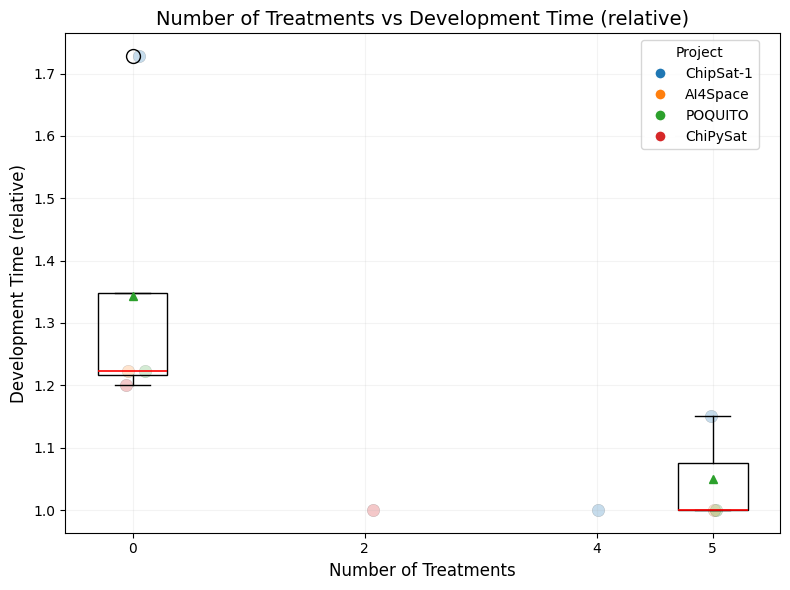

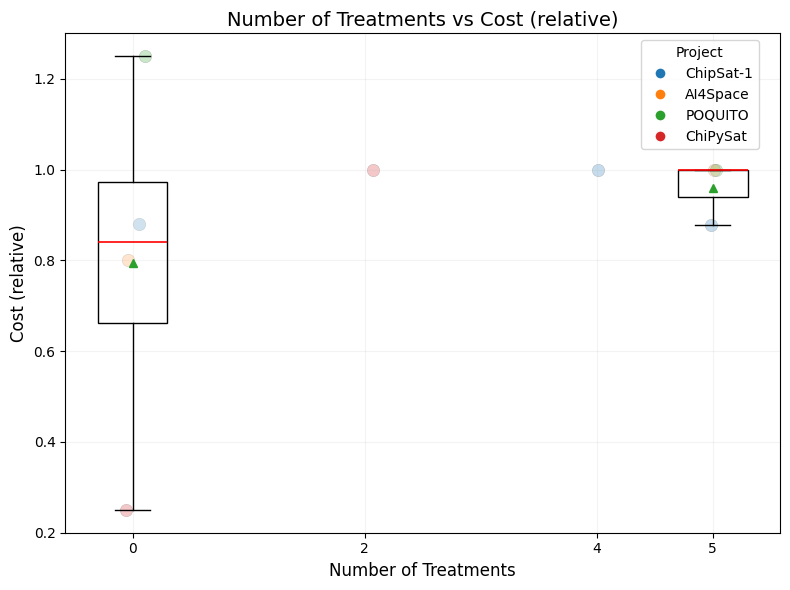

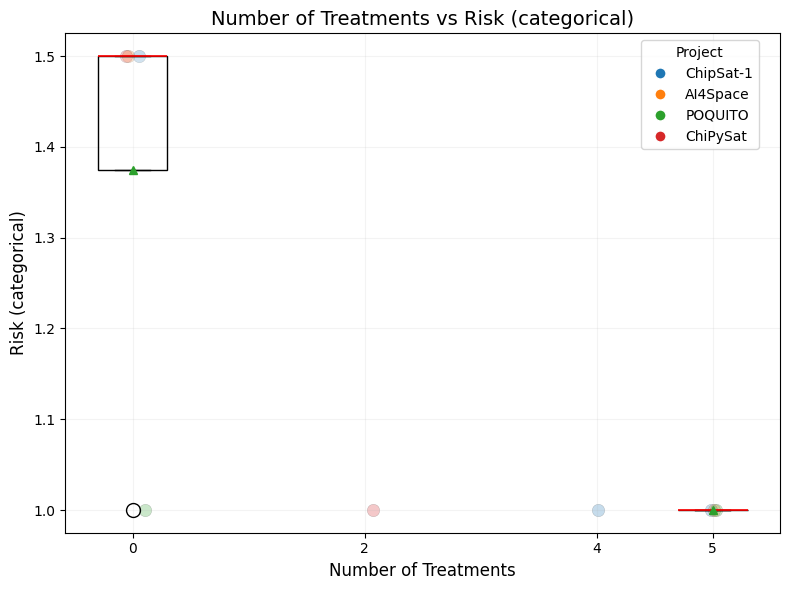

In [75]:

for parameter in df_copy.columns[3:]:
    parameter_alias = parameter.split()[0].lower()
    label = label_map[parameter]

    treatments = np.sort(df_copy['Number of Treatments'].unique())
    data_by_t = [df_copy.loc[df_copy['Number of Treatments'] == t, parameter].values for t in treatments]

    fig, ax = plt.subplots(figsize=(8, 6))

    # scatter background: jitter points and color by project
    rng = np.random.default_rng(0)
    for proj in projects:
        proj_mask = df_copy['Project'] == proj
        xs = df_copy.loc[proj_mask, 'Number of Treatments'].values
        ys = df_copy.loc[proj_mask, parameter].values
        if len(xs):
            jitter = rng.normal(0, 0.08, size=len(xs))
            ax.scatter(xs + jitter, ys, color=colors.get(proj, 'gray'), alpha=0.25, s=80, edgecolors='k', linewidths=0.3, zorder=1)

    # filter treatments with 1 data only
    data_by_t = [data if len(data) > 1 else np.array([]) for data in data_by_t]

    bp = ax.boxplot(data_by_t, positions=treatments, widths=0.6, patch_artist=True, notch=False, manage_ticks=False, zorder=2, showmeans=True)
    # style boxes to be transparent so background points remain visible
    for box in bp['boxes']:
        box.set(facecolor=(1, 1, 1, 0.2), edgecolor='black', linewidth=1.0)
    # for whisker in bp['whiskers']:
    #     whisker.set(color='black', linewidth=0.8)
    # for cap in bp['caps']:
    #     cap.set(color='black', linewidth=0.8)
    for median in bp['medians']:
        median.set(color='red', linewidth=1.2)
    for flier in bp['fliers']:
        flier.set(marker='o', color='black', alpha=1, linewidth=1, ms=10)

    ax.set_xlabel('Number of Treatments', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'Number of Treatments vs {label}', fontsize=14)
    ax.set_xticks(treatments)
    ax.grid(True, alpha=0.15)

    # legend for projects
    handles = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[p], markersize=8, label=p) for p in projects]
    ax.legend(handles=handles, title='Project', bbox_to_anchor=(0.98, 1), loc='upper right')

    plt.tight_layout()
    plt.savefig(f"sensitivity_boxplot_{parameter_alias}{specifier}.pdf", dpi=300)
    #plt.show()

    print(f"Parameter: {label}")
    # Mann-Whitney U test
    print(scipy.stats.mannwhitneyu(df_copy.loc[df_copy['Number of Treatments'] == 0, parameter],
                                   df_copy.loc[df_copy['Number of Treatments'] == 5, parameter],
                                   alternative='two-sided',
                                   method='exact'))
    # Student T-test
    print(scipy.stats.ttest_ind(df_copy.loc[df_copy['Number of Treatments'] == 0, parameter],
                                df_copy.loc[df_copy['Number of Treatments'] == 5, parameter],
                                alternative='two-sided',
                                equal_var=False))

## Sensitivity analysis

Parameter: Development Time (hours)
  Min: 1.0
  Max: 1.7280334728033473
  Mean: 1.1692339480345058
  Std: 0.23284267369144623

   number of treatments  project #  Development Time (relative)
0                   4.0          1                     1.000000
1                   5.0          1                     1.150628
2                   0.0          1                     1.728033
3                   5.0          2                     1.000000
4                   0.0          2                     1.222222
5                   5.0          3                     1.000000
6                   0.0          3                     1.222222
7                   2.0          4                     1.000000
8                   0.0          4                     1.200000
=== ANALYSIS FOR PARAMETER: Development Time (hours) ===
                       minimum      mean    median   maximum        CV  \
number of treatments  0.555556  0.555556  0.555556  0.555556  0.000000   
project #             0.166

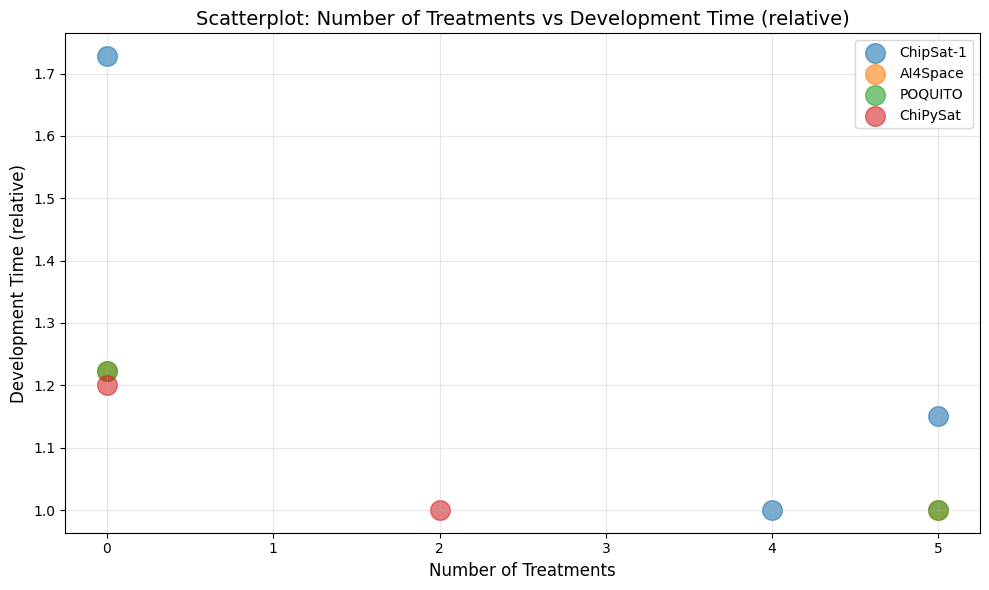

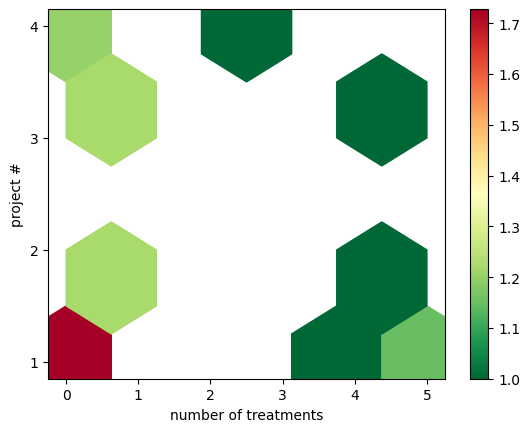

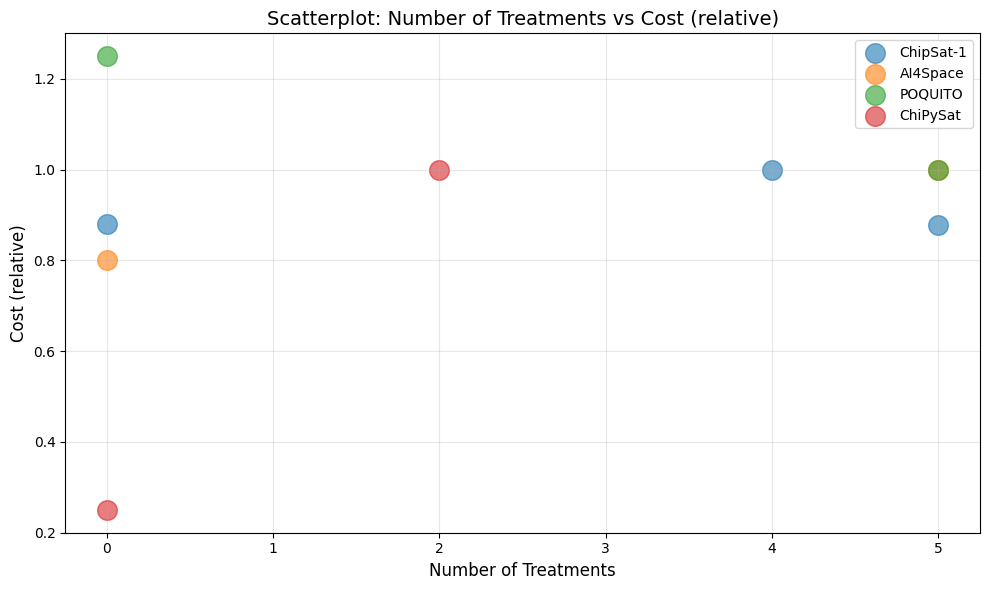

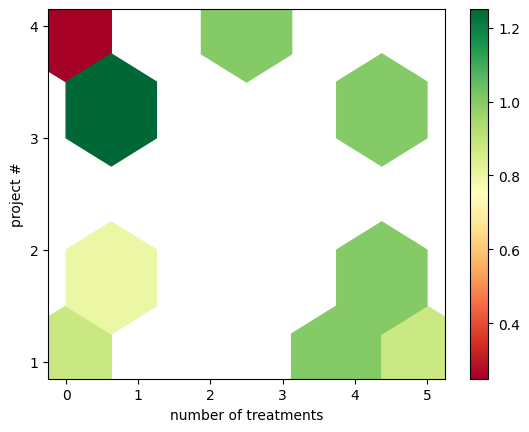

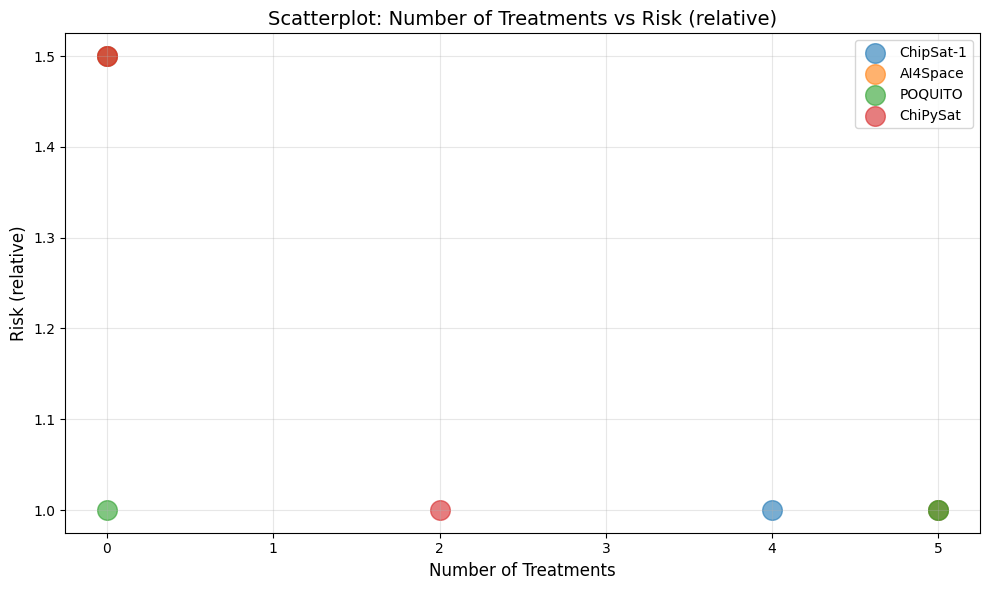

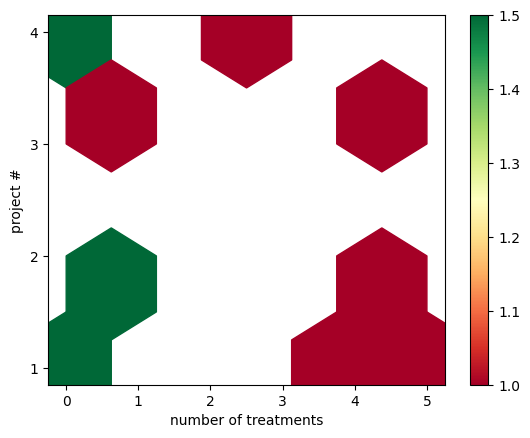

In [65]:
# Sensitivity analysis

for parameter in df_copy.columns[3:]:
    print(f"Parameter: {parameter}")
    print(f"  Min: {df_copy[parameter].min()}")
    print(f"  Max: {df_copy[parameter].max()}")
    print(f"  Mean: {df_copy[parameter].mean()}")
    print(f"  Std: {df_copy[parameter].std()}")
    print()

    fig, ax = plt.subplots(figsize=(10, 6))
    
    for project in projects:
        project_data = df_copy[df_copy['Project'] == project]

        ax.scatter(project_data['Number of Treatments'], 
                project_data[parameter], 
                s=200, alpha=0.6, 
                color=colors[project], 
                label=project)
    
    # Add labels for each point
    for idx, row in df_copy.iterrows():
        label = row['Project'] + " " + row['Analysis Type']
        #ax.annotate(label, (row['Number of Treatments'], row[parameter]), 
        #           fontsize=9, alpha=0.7)

    parameter_alias = parameter.split()[0].lower()
    label = parameter
    if relative:
        label = label.split('(')[0].strip() + " (relative)"
    
    ax.set_xlabel('Number of Treatments', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'Scatterplot: Number of Treatments vs {label}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    #plt.show()
    plt.savefig(f"sensitivity_scatter_{parameter_alias}.pdf", dpi=150)

    # SENSITIVTY ANALYSIS
    # x1 = number of treatments
    x1 = df_copy['Number of Treatments'].values
    # x2 = project index
    x2 = np.where(df_copy['Project'].values[:, None] == projects)[1] + 1
    # y = output value
    y = df_copy[parameter].values

    # Create a list of (x1, x2, y) tuples
    inputs = list(zip(x1, x2))
    outputs = list(zip(x1, x2, y))
    df_sens = pd.DataFrame(outputs, columns=['number of treatments', 'project #', label])
    print(df_sens)

    cmap = 'RdYlGn_r' if 'time' in label.lower() else 'RdYlGn'

    plt_sens = df_sens.plot.hexbin(x='number of treatments', y='project #', C=label, gridsize=len(projects), cmap=cmap, sharex=False)
    plt_sens.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    specifier = "_relative" if relative else "_absolute"
    plt_sens.figure.savefig(f"sensitivity_hexbin_{parameter_alias}{specifier}.pdf", dpi=300)

    problem = {
        'num_vars': 2,
        'names': ['number of treatments', 'project #'],
        # 'bounds': [[1, 5], [1, len(projects)]]
    }

    print(f"=== ANALYSIS FOR PARAMETER: {parameter} ===")
    analysis = pawn.analyze(problem, np.array(inputs), np.array(y), print_to_console=True)
    print("")

names notes  delta_balanced  delta_step  delta_raw  delta_balanced_conf  delta_step_conf  delta_raw_conf       s1  s1_conf
   x1              0.151725    0.174591   0.116291             0.018582         0.015842        0.018849 0.113340 0.035940
   x2              0.482800    0.480524   0.446182             0.015799         0.016262        0.018170 0.782600 0.020352
   x3              0.045519    0.059664   0.057433             0.015668         0.014598        0.015494 0.007473 0.010579
    minimum      mean  median  maximum        CV     stdev
x1    0.124  0.227000  0.2295    0.337  0.271181  0.061558
x2    0.321  0.524939  0.5060    0.727  0.252261  0.132422
x3    0.043  0.083417  0.0885    0.105  0.197768  0.016497


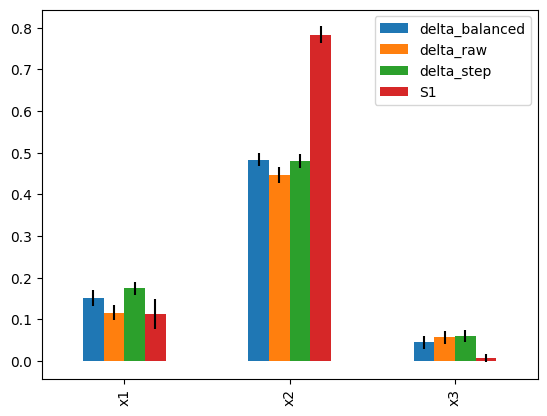

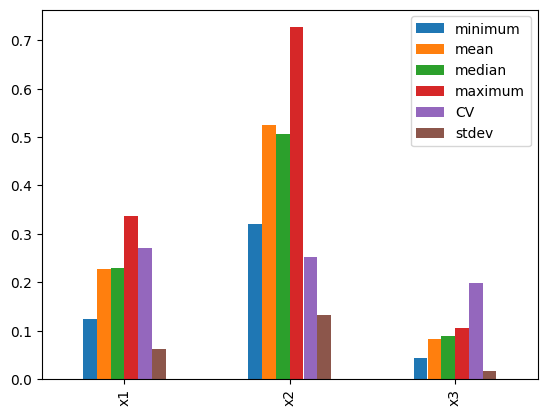

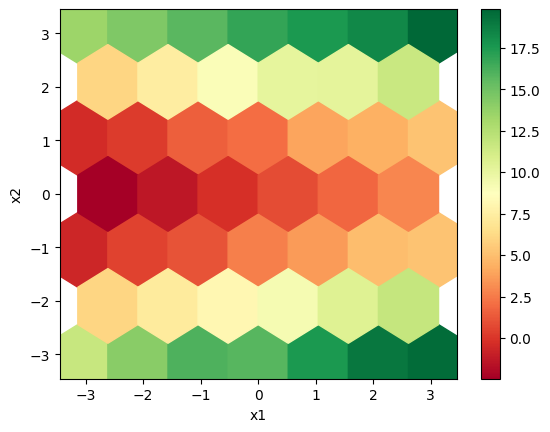

In [ ]:
# Experimental sheet (do not use)

from SALib.sample import latin
from SALib.test_functions import Ishigami
from SALib.analyze import dgsm,hdmr,discrepancy,delta,pawn
import numpy as np
import pandas as pd

problem = {
    'num_vars': 3,
    'names': ['x1', 'x2', 'x3'],
    'bounds': [[-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359]]
}

X = latin.sample(problem, 1000)
#Y = Ishigami.evaluate(X)

def model_one(x):
    return x[0] + 2 * (x[1] ** 2)
Y = np.array([model_one(x) for x in X])

# The delta method provides nice information about how much an input affects variation in the output in terms of both importance and impact. But it doesn't seem to be working well for small sample sizes.
Si = delta.analyze(problem, X, Y, print_to_console=True)
Si.plot()

# Pawn is more robust to small sample sizes, but doesn't provide confidence intervals.
Si = pawn.analyze(problem, X, Y, print_to_console=True)
Si.plot()

df_sens = pd.DataFrame(X, columns=problem['names'])
df_sens['output'] = Y

plt_sens = df_sens.plot.hexbin(x='x1', y='x2', C='output', gridsize=6, cmap='RdYlGn', sharex=False)